In [9]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

from collections import Counter
from wordcloud import WordCloud

In [10]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
df = pd.read_excel("/content/finalDataset0.2.xlsx")

print("Student Feedback Dataset")

print(df.head())

print("\nColumn Names")

print(df.columns)

Student Feedback Dataset
   teaching                                         teaching.1  coursecontent  \
0         0  teacher are punctual but they should also give...            0.0   
1         1                                              Good            -1.0   
2         1  Excellent lectures are delivered by teachers a...            1.0   
3         1                                               Good           -1.0   
4         1  teachers give us all the information required ...            1.0   

                                     coursecontent.1  examination  \
0                     content of courses are average          1.0   
1                                           Not good          1.0   
2  All courses material provide very good knowled...          1.0   
3  Content of course is perfectly in line with th...         -1.0   
4           content of courses improves my knowledge          1.0   

                                         Examination  labwork  \
0       

In [12]:
feedback_data = []

areas = [
    ("teaching", "teaching.1", "Teaching"),
    ("coursecontent", "coursecontent.1", "Course Content"),
    ("examination", "Examination", "Examination"),
    ("labwork", "labwork.1", "Lab Work"),
    ("library_facilities", " library_facilities", "Library Facilities"),
    ("extracurricular", "extracurricular.1", "Extracurricular")
]

for label_column, text_column, area in areas:

    temp = df[[label_column, text_column]].copy()

    temp.columns = ["Sentiment", "Feedback"]

    temp["Area"] = area

    feedback_data.append(temp)

df = pd.concat(feedback_data, ignore_index=True)

df = df.dropna()

print("Prepared Student Feedback Dataset")

print(df.head())

print("\nDataset Size")

print(df.shape)

Prepared Student Feedback Dataset
   Sentiment                                           Feedback      Area
0        0.0  teacher are punctual but they should also give...  Teaching
1        1.0                                              Good   Teaching
2        1.0  Excellent lectures are delivered by teachers a...  Teaching
3        1.0                                               Good  Teaching
4        1.0  teachers give us all the information required ...  Teaching

Dataset Size
(1105, 3)


In [13]:
print(df["Sentiment"].value_counts())

Sentiment
 1.0    808
 0.0    150
-1.0    147
Name: count, dtype: int64


In [14]:
def convert_sentiment(label):

    if label == 1:

        return "Positive"

    elif label == -1:

        return "Negative"

    else:

        return "Neutral"

df["Sentiment"] = df["Sentiment"].apply(convert_sentiment)

print(df.head())

print("\nSentiment Distribution")

print(df["Sentiment"].value_counts())

  Sentiment                                           Feedback      Area
0   Neutral  teacher are punctual but they should also give...  Teaching
1  Positive                                              Good   Teaching
2  Positive  Excellent lectures are delivered by teachers a...  Teaching
3  Positive                                               Good  Teaching
4  Positive  teachers give us all the information required ...  Teaching

Sentiment Distribution
Sentiment
Positive    808
Neutral     150
Negative    147
Name: count, dtype: int64


In [15]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned_Feedback"] = df["Feedback"].apply(clean_text)

print(df[["Feedback","Cleaned_Feedback"]].head())

                                            Feedback  \
0  teacher are punctual but they should also give...   
1                                              Good    
2  Excellent lectures are delivered by teachers a...   
3                                               Good   
4  teachers give us all the information required ...   

                                    Cleaned_Feedback  
0  teacher punctual also give us practical knowle...  
1                                               good  
2  excellent lectures delivered teachers teachers...  
3                                               good  
4  teachers give us information required improve ...  


In [16]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["Cleaned_Feedback"])

y = df["Sentiment"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

In [18]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [19]:
y_pred = model.predict(X_test)

print("Predicted Sentiments")

print(y_pred)

Predicted Sentiments
['Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Neutral' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Neutral' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive

In [20]:
feedback = [

    "The teacher explains concepts very clearly.",

    "The assignments are very difficult and stressful.",

    "The laboratory facilities need improvement.",

    "The library has an excellent collection of books.",

    "More practical classes should be conducted."

]

clean_feedback = []

for text in feedback:

    clean_feedback.append(clean_text(text))

feedback_vector = vectorizer.transform(clean_feedback)

prediction = model.predict(feedback_vector)

for text, sentiment in zip(feedback, prediction):

    print(text)

    print("Sentiment :", sentiment)

    print()

The teacher explains concepts very clearly.
Sentiment : Positive

The assignments are very difficult and stressful.
Sentiment : Positive

The laboratory facilities need improvement.
Sentiment : Positive

The library has an excellent collection of books.
Sentiment : Positive

More practical classes should be conducted.
Sentiment : Positive



In [21]:
concerns = df[df["Sentiment"].isin(["Negative", "Neutral"])]

concern_count = concerns["Area"].value_counts()

print("Common Student Concerns")

print(concern_count)

Common Student Concerns
Area
Course Content        56
Library Facilities    55
Examination           54
Lab Work              53
Teaching              48
Extracurricular       31
Name: count, dtype: int64


In [22]:
concern_words = " ".join(concerns["Cleaned_Feedback"])

word_list = concern_words.split()

word_freq = Counter(word_list)

print("Top 10 Common Concern Words")

print(word_freq.most_common(10))

Top 10 Common Concern Words
[('good', 102), ('books', 38), ('students', 27), ('average', 27), ('teachers', 24), ('course', 23), ('time', 22), ('lab', 21), ('dont', 20), ('library', 20)]


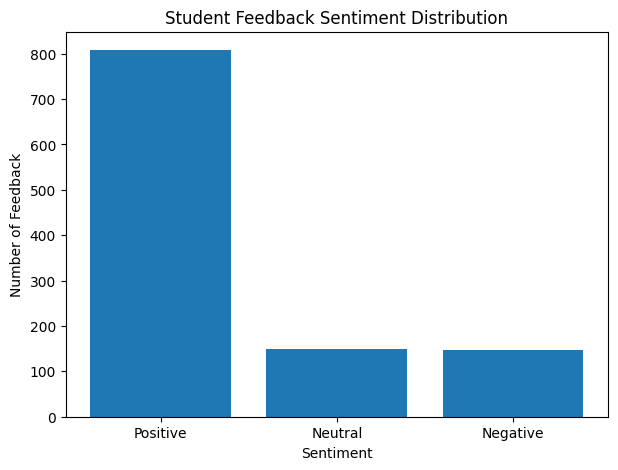

In [23]:
sentiment_count = df["Sentiment"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(sentiment_count.index, sentiment_count.values)

plt.title("Student Feedback Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Number of Feedback")

plt.show()

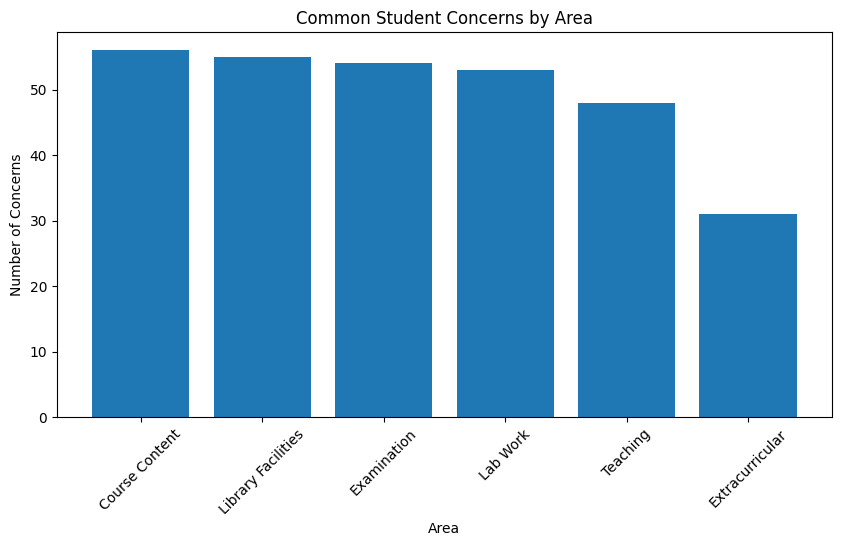

In [24]:
plt.figure(figsize=(10,5))

plt.bar(concern_count.index, concern_count.values)

plt.title("Common Student Concerns by Area")

plt.xlabel("Area")

plt.ylabel("Number of Concerns")

plt.xticks(rotation=45)

plt.show()

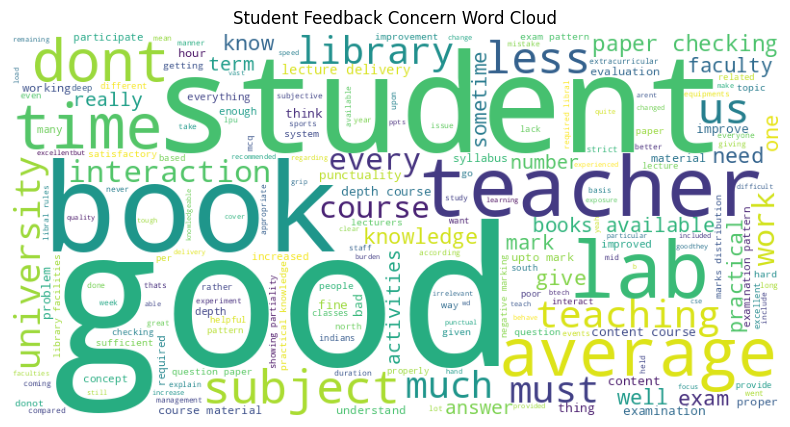

In [25]:
wordcloud = WordCloud(

    width=800,

    height=400,

    background_color="white"

).generate(concern_words)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Student Feedback Concern Word Cloud")

plt.show()

In [26]:
positive = len(df[df["Sentiment"]=="Positive"])

negative = len(df[df["Sentiment"]=="Negative"])

neutral = len(df[df["Sentiment"]=="Neutral"])

print("Student Feedback Analysis Report")

print("-----------------------------------")

print("Positive Feedback :", positive)

print("Negative Feedback :", negative)

print("Neutral Feedback :", neutral)

print("\nCommon Student Concerns")

print(concern_count)

print("\nTop Concern Keywords")

print(word_freq.most_common(10))

print("\nImprovement Suggestions")

print("The institution should focus on areas receiving higher negative and neutral feedback. Improvements can include clearer teaching methods, more practical learning activities, better laboratory facilities, balanced examinations, improved library resources, and meaningful extracurricular activities.")

Student Feedback Analysis Report
-----------------------------------
Positive Feedback : 808
Negative Feedback : 147
Neutral Feedback : 150

Common Student Concerns
Area
Course Content        56
Library Facilities    55
Examination           54
Lab Work              53
Teaching              48
Extracurricular       31
Name: count, dtype: int64

Top Concern Keywords
[('good', 102), ('books', 38), ('students', 27), ('average', 27), ('teachers', 24), ('course', 23), ('time', 22), ('lab', 21), ('dont', 20), ('library', 20)]

Improvement Suggestions
The institution should focus on areas receiving higher negative and neutral feedback. Improvements can include clearer teaching methods, more practical learning activities, better laboratory facilities, balanced examinations, improved library resources, and meaningful extracurricular activities.
